Saving Dataset (1).csv to Dataset (1) (1).csv
✅ Dataset loaded successfully.
Columns: ['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address', 'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines', 'Average Cost for two', 'Currency', 'Has Table booking', 'Has Online delivery', 'Is delivering now', 'Switch to order menu', 'Price range', 'Aggregate rating', 'Rating color', 'Rating text', 'Votes']
                           Cuisines  Aggregate rating  Votes
0        French, Japanese, Desserts               4.8    314
1                          Japanese               4.5    591
2  Seafood, Asian, Filipino, Indian               4.4    270
3                   Japanese, Sushi               4.9    365
4                  Japanese, Korean               4.8    229


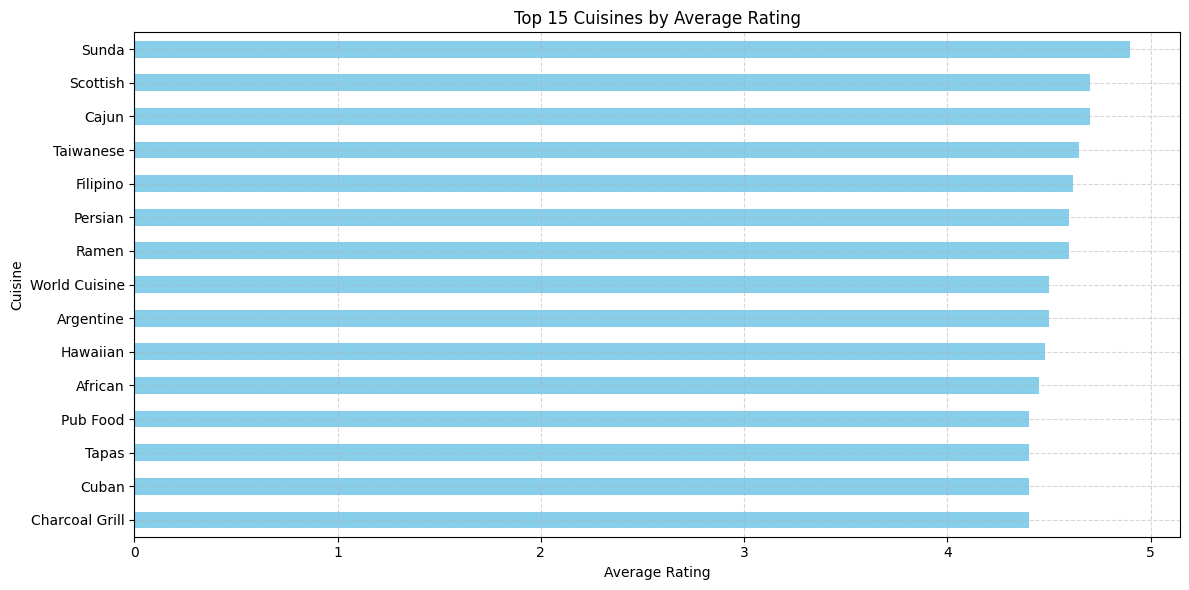

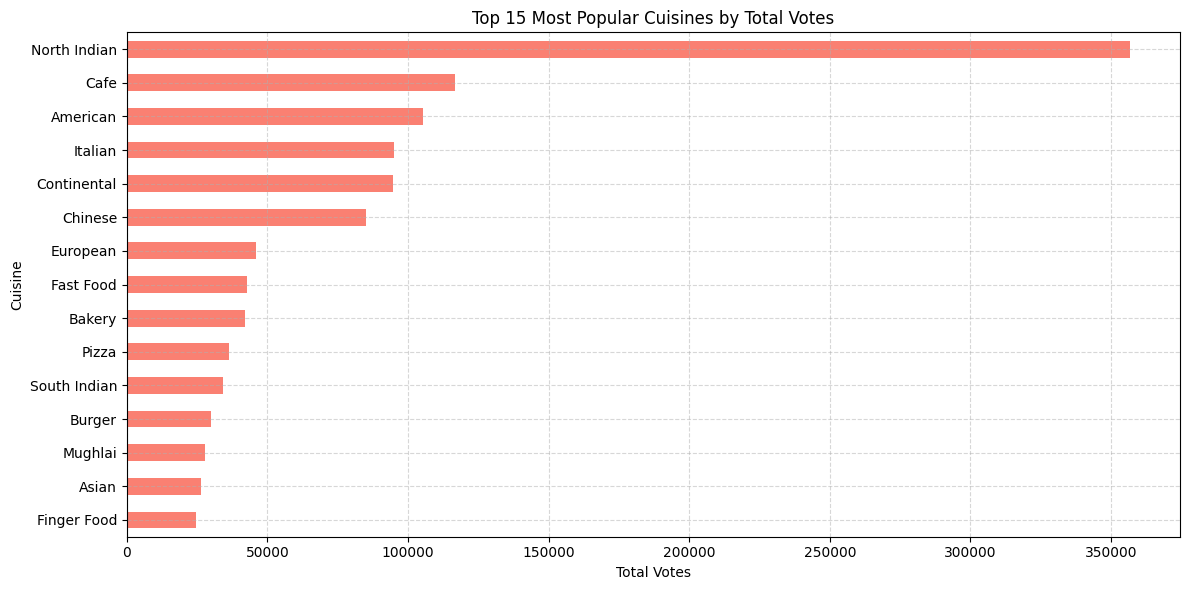

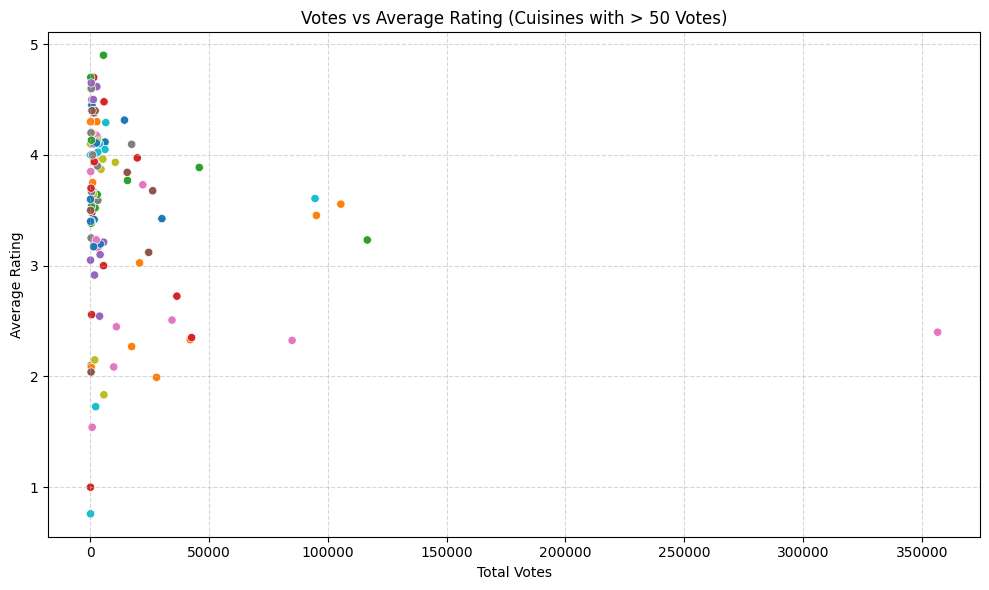

In [3]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

uploaded = files.upload()
filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)
print("✅ Dataset loaded successfully.")
print("Columns:", df.columns.tolist())
print(df[['Cuisines', 'Aggregate rating', 'Votes']].head())

df = df[['Cuisines', 'Aggregate rating', 'Votes']].dropna()
df['Cuisines'] = df['Cuisines'].astype(str).apply(lambda x: x.split(',')[0].strip())
avg_rating = df.groupby('Cuisines')['Aggregate rating'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
avg_rating.head(15).plot(kind='barh', color='skyblue')
plt.title("Top 15 Cuisines by Average Rating")
plt.xlabel("Average Rating")
plt.ylabel("Cuisine")
plt.gca().invert_yaxis()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

popular_cuisines = df.groupby('Cuisines')['Votes'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
popular_cuisines.head(15).plot(kind='barh', color='salmon')
plt.title("Top 15 Most Popular Cuisines by Total Votes")
plt.xlabel("Total Votes")
plt.ylabel("Cuisine")
plt.gca().invert_yaxis()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
grouped = df.groupby('Cuisines').agg({
    'Aggregate rating': 'mean',
    'Votes': 'sum'
}).reset_index()

filtered_grouped = grouped[grouped['Votes'] > 50]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=filtered_grouped, x='Votes', y='Aggregate rating', hue='Cuisines', legend=False, palette='tab10')
plt.title("Votes vs Average Rating (Cuisines with > 50 Votes)")
plt.xlabel("Total Votes")
plt.ylabel("Average Rating")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
